# Movie Marketing Asset Generator — Evaluation Notebook
**Group 5 | INFO 290 | Nseke Ngilbus**

This notebook evaluates the three system variants (V1, V2, V3) using LLM-as-Judge scoring across the five qualitative dimensions defined in the milestone report:

| Dimension | Description |
|---|---|
| `narrative_fidelity` | Output follows intended premise without adding unintended plot elements |
| `genre_alignment` | Output matches the intended genre and tone |
| `visual_specificity` | Poster description includes concrete visual elements |
| `creative_specificity` | Output contains distinctive and non-generic phrasing |
| `output_format_validity` | Output follows required JSON structure |

Outputs are compared across variants using bar charts, radar charts, and per-dimension breakdowns.

In [ ]:
# Cell 0: Install dependencies
!pip -q install "transformers>=4.41" "accelerate>=0.30" bitsandbytes \
                 sentence-transformers faiss-cpu pandas numpy requests tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 45.7 MB/s eta 0:00:00


In [ ]:
# Cell 1: Imports & credentials
import os
import json
import re
import numpy as np
import pandas as pd
import requests
import torch
import faiss
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import pi
from pprint import pprint
from tqdm import tqdm
from google.colab import userdata

TMDB_BEARER  = userdata.get("TMDB_BEARER")
HF_TOKEN     = userdata.get("HF_TOKEN")
GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

print("✅ Imports done")

✅ Imports done


In [ ]:
# Cell 2: Clone repo and load dataset
import os
GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

ret = os.system(f"git clone https://{GITHUB_TOKEN}@github.com/ryuichi-github/ryuichi-github-info290-2026s-group5.git")
print("Clone return code:", ret)

REPO_ROOT = "ryuichi-github-info290-2026s-group5"
print("Folder exists:", os.path.exists(REPO_ROOT))

import pandas as pd
file_path = os.path.join(REPO_ROOT, "tmdb-fetch/tmdb_movies.csv")
movies_df = pd.read_csv(file_path)
print(f"✅ Loaded {len(movies_df)} movies")
print(movies_df.columns.tolist())

Clone return code: 0
Folder exists: True
✅ Loaded 4816 movies
['id', 'title', 'tagline', 'overview', 'release_date', 'genre_ids', 'genre_names', 'vote_average', 'vote_count', 'popularity', 'poster_path', 'backdrop_path', 'runtime', 'original_language', 'status', 'revenue', 'budget', 'belongs_to_collection']


In [ ]:
# Cell 3: TMDB genre mapping
def tmdb_get(url, params=None):
    headers = {
        "Authorization": f"Bearer {TMDB_BEARER}",
        "Content-Type": "application/json;charset=utf-8"
    }
    r = requests.get(url, headers=headers, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

genre_data = tmdb_get("https://api.themoviedb.org/3/genre/movie/list", params={"language": "en-US"})
GENRE_ID_TO_NAME = {g["id"]: g["name"] for g in genre_data.get("genres", [])}
GENRE_NAME_TO_ID = {v.lower(): k for k, v in GENRE_ID_TO_NAME.items()}

print(f"✅ Genres loaded: {len(GENRE_ID_TO_NAME)}")

✅ Genres loaded: 19


In [ ]:
# Cell 4: Build RAG corpus + FAISS index
from sentence_transformers import SentenceTransformer

corpus_df = movies_df[
    movies_df["tagline"].notna() & (movies_df["tagline"].str.strip() != "")
].copy().reset_index(drop=True)

print(f"Corpus size: {len(corpus_df)} movies")

embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

corpus_texts = (
    corpus_df["title"] + " " + corpus_df["tagline"] + " " + corpus_df["overview"]
).tolist()

embeddings = embed_model.encode(
    corpus_texts,
    normalize_embeddings=True,
    show_progress_bar=True
).astype("float32")

dim = embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(embeddings)

print(f"✅ FAISS index ready: {faiss_index.ntotal} vectors")

Corpus size: 4312 movies


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/135 [00:00<?, ?it/s]

✅ FAISS index ready: 4312 vectors


In [ ]:
# Cell 5: Load LLM (Mistral-7B-Instruct-v0.2, 4-bit quantized)
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN,
    device_map="auto",
    quantization_config=bnb_config,
)

print("✅ Model loaded on:", model.device)

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ Model loaded on: cuda:0


In [ ]:
# Cell 6: Core helper functions (shared across V1/V2/V3)

def _normalize_genre_filter(genre_filter):
    if genre_filter is None:
        return None
    if isinstance(genre_filter, (list, tuple)) and len(genre_filter) > 0:
        if isinstance(genre_filter[0], str):
            ids = [GENRE_NAME_TO_ID[name.lower()] for name in genre_filter
                   if name.lower() in GENRE_NAME_TO_ID]
            return ids if ids else []
        if isinstance(genre_filter[0], int):
            return list(genre_filter)
    raise ValueError("genre_filter must be None, list of genre names, or list of genre ids.")


def retrieve(query: str, k: int = 5, genre_filter=None) -> pd.DataFrame:
    q = embed_model.encode([query], normalize_embeddings=True).astype("float32")
    gf_ids = _normalize_genre_filter(genre_filter)

    if gf_ids is None:
        scores, idx = faiss_index.search(q, k)
        out = corpus_df.iloc[idx[0]].copy()
        out["score"] = scores[0]
        return out.reset_index(drop=True)

    gf_ids = set(gf_ids)
    mask = corpus_df["genre_ids"].apply(
        lambda gids: any(gid in gf_ids for gid in eval(gids))
    ).to_numpy()
    candidate_idx = np.where(mask)[0]

    if candidate_idx.size == 0:
        scores, idx = faiss_index.search(q, k)
        out = corpus_df.iloc[idx[0]].copy()
        out["score"] = scores[0]
        out["note"] = "No genre-filtered candidates; fell back to unfiltered."
        return out.reset_index(drop=True)

    cand_emb = embeddings[candidate_idx]
    scores = cand_emb @ q[0]
    topk_local = np.argsort(-scores)[:k]
    topk_idx = candidate_idx[topk_local]
    out = corpus_df.iloc[topk_idx].copy()
    out["score"] = scores[topk_local]
    return out.reset_index(drop=True)


def refs_to_text(df: pd.DataFrame, n: int = 5) -> str:
    lines = []
    for _, r in df.head(n).iterrows():
        if pd.notna(r["tagline"]) and r["tagline"].strip():
            ov = (r["overview"] or "")[:200].replace("\n", " ")
            lines.append(f'- {r["title"]}: tagline: "{r["tagline"]}" | overview: "{ov}"')
    return "\n".join(lines)


def generate_text(prompt: str, max_new_tokens: int = 320) -> str:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.6,
            top_p=0.9,
            repetition_penalty=1.10,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


REQUIRED_KEYS = {"overview", "tagline", "poster_art_direction"}

def extract_best_json(text: str) -> dict:
    decoder = json.JSONDecoder()
    objs = []
    i = 0
    while True:
        start = text.find("{", i)
        if start == -1:
            break
        try:
            obj, end = decoder.raw_decode(text[start:])
            objs.append(obj)
            i = start + end
        except json.JSONDecodeError:
            i = start + 1
    if not objs:
        raise ValueError("No JSON object found in model output.")

    def score(obj):
        if not isinstance(obj, dict):
            return -10
        if not REQUIRED_KEYS.issubset(set(obj.keys())):
            return -5
        s = 0
        tagline  = obj.get("tagline", "")
        poster   = obj.get("poster_art_direction", "")
        overview = obj.get("overview", "")
        if isinstance(tagline, str) and len(tagline.strip()) > 0:
            s += 2
            if len(tagline.split()) <= 14:
                s += 1
        if isinstance(poster, str) and len(poster.strip()) > 20:
            s += 2
        if isinstance(overview, str) and len(overview.strip()) > 40:
            s += 2
        return s

    return max(objs, key=score)


print("✅ Core functions ready")

✅ Core functions ready


In [ ]:
# Cell 7: V1 and V2 generation functions

def build_prompt(user_setting: str, refs: str) -> str:
    return f"""You are a movie marketing generator.

The user has described their movie idea below. Based on this, generate marketing assets.

OUTPUT: ONE JSON object with EXACTLY these keys:
- overview (<= 80 words, compelling promo synopsis)
- tagline (<= 12 words)
- poster_art_direction (<= 60 words)

JSON FORMAT:
{{"overview": "", "tagline": "", "poster_art_direction": ""}}

USER'S MOVIE IDEA:
{user_setting}

REFERENCES from similar successful movies (use as inspiration for tone and style; do NOT copy):
{refs}

CONSTRAINTS:
- Output ONLY the JSON object (no markdown, no backticks, no commentary).
- tagline must be original and specific to this movie, not generic.
- overview must be written as compelling promo copy, not a plot summary.
- End immediately after the final '}}'.

Now output the JSON:
"""


def run_v1(user_setting: str) -> dict:
    """V1: Zero-shot baseline, no retrieval."""
    prompt = build_prompt(user_setting, refs="(none)")
    raw = generate_text(prompt)
    return extract_best_json(raw)


def run_v2(user_setting: str, k: int = 5, genre_filter=None) -> dict:
    """V2: RAG-grounded generation."""
    topk = retrieve(user_setting, k=k, genre_filter=genre_filter)
    refs = refs_to_text(topk, n=k)
    prompt = build_prompt(user_setting, refs=refs)
    raw = generate_text(prompt)
    return extract_best_json(raw)


print("✅ V1/V2 runners ready")

✅ V1/V2 runners ready


In [ ]:
# Cell 8: V3 agentic loop (judge-then-refine, adapted from Shivani's implementation)

def make_gen_prompt(user_setting, refs, feedback=""):
    fb_block = f"PREVIOUS FEEDBACK:\n{feedback}" if feedback else ""
    return f"""You are a movie marketing generator.

The user has described their movie idea below. Based on this, generate marketing assets.

OUTPUT: ONE JSON object with EXACTLY these keys:
- overview (<= 80 words, compelling promo synopsis)
- tagline (<= 12 words)
- poster_art_direction (<= 60 words)

JSON FORMAT:
{{"overview": "", "tagline": "", "poster_art_direction": ""}}

USER'S MOVIE IDEA:
{user_setting}

REFERENCES:
{refs}

{fb_block}

CONSTRAINTS:
- Output ONLY the JSON object.
- tagline must be specific to this movie.
- overview must be promo copy, not a plot summary.
- End immediately after the final '}}'.

Now output the JSON:
"""


def make_judge_prompt(user_setting, assets):
    return f"""You are a film marketing evaluator.
Score the marketing assets below from 1-5 on each dimension.

MOVIE IDEA:
{user_setting}

ASSETS:
{assets}

DIMENSIONS:
1. narrative_fidelity - does it stick to the premise
2. genre_alignment - does it match the genre/tone
3. visual_specificity - is the poster description specific
4. creative_specificity - is the tagline original
5. output_format_validity - is it valid JSON with all keys

OUTPUT this JSON with integer scores and one feedback sentence:
{{"narrative_fidelity": 0, "genre_alignment": 0, "visual_specificity": 0, "creative_specificity": 0, "output_format_validity": 0, "feedback": "what needs fixing"}}

Only output the JSON, nothing else.
"""


def run_v3(user_setting, k=5, genre_filter=None, max_iter=3):
    """V3: Agentic RAG with judge-refine loop."""
    topk = retrieve(user_setting, k=k, genre_filter=genre_filter)
    refs = refs_to_text(topk, n=k)
    feedback = ""
    history = []

    for i in range(max_iter):
        gen_prompt = make_gen_prompt(user_setting, refs, feedback)
        result = generate_text(gen_prompt)

        try:
            assets = extract_best_json(result)
        except:
            history.append({"iter": i+1, "assets": None, "scores": None, "passed": False})
            continue

        judge_prompt = make_judge_prompt(user_setting, json.dumps(assets))
        judge_raw = generate_text(judge_prompt)

        try:
            scores_out = extract_best_json(judge_raw)
        except:
            history.append({"iter": i+1, "assets": assets, "scores": None, "passed": False})
            continue

        score_keys = ["narrative_fidelity", "genre_alignment", "visual_specificity",
                      "creative_specificity", "output_format_validity"]
        scores = {k: int(scores_out.get(k, 0)) for k in score_keys}
        feedback = scores_out.get("feedback", "")
        passed = all(v >= 3 for v in scores.values())

        history.append({"iter": i+1, "assets": assets, "scores": scores, "passed": passed})

        if passed:
            break

    best = next((h for h in reversed(history) if h["assets"] is not None), None)
    return best["assets"] if best else None, history


print("✅ V3 agentic loop ready")

✅ V3 agentic loop ready


---
## Evaluation

We run all three variants on a fixed set of test prompts, then score each output using the LLM-as-Judge module. Results are compared across variants using bar charts and radar plots.

In [ ]:
# Cell 9: Define evaluation test prompts
# Each entry is a structured movie input (core_premise + thematic_core + negative_constraints)
# covering different genres to stress-test all variants.

TEST_PROMPTS = [
    {
        "id": "thriller_01",
        "genre": ["thriller", "horror", "mystery"],
        "text": (
            "core_premise: a rural clinic cut off by flooding during a storm. "
            "thematic_core: paranoia and distrust among strangers trapped together. "
            "negative_constraints: no invented characters, no disappearances, no supernatural elements."
        )
    },
    {
        "id": "scifi_01",
        "genre": ["science fiction", "drama"],
        "text": (
            "core_premise: a deep-space engineer discovers her ship's AI has been hiding crew deaths. "
            "thematic_core: the cost of truth when survival depends on ignorance. "
            "negative_constraints: no alien encounters, no action sequences, no romance subplot."
        )
    },
    {
        "id": "drama_01",
        "genre": ["drama", "family"],
        "text": (
            "core_premise: a retired Olympic swimmer coaches her estranged daughter at a small-town pool. "
            "thematic_core: reconciling ambition with belonging. "
            "negative_constraints: no competition win ending, no injury drama, no love interest."
        )
    },
]

print(f"✅ {len(TEST_PROMPTS)} test prompts defined")

✅ 3 test prompts defined


In [ ]:
# Cell 10: LLM-as-Judge scoring function
# Standalone scorer — takes any assets dict and a movie idea and returns dimension scores.

SCORE_KEYS = [
    "narrative_fidelity",
    "genre_alignment",
    "visual_specificity",
    "creative_specificity",
    "output_format_validity",
]

def judge_assets(user_setting: str, assets: dict) -> dict:
    """
    Score a single assets dict using the LLM-as-Judge prompt.
    Returns a dict with 5 integer scores (1-5) and a feedback string.
    Returns None for all scores if parsing fails.
    """
    prompt = make_judge_prompt(user_setting, json.dumps(assets))
    raw = generate_text(prompt)
    try:
        result = extract_best_json(raw)
        scores = {k: int(result.get(k, 0)) for k in SCORE_KEYS}
        scores["feedback"] = result.get("feedback", "")
        return scores
    except Exception as e:
        print(f"  ⚠️  Judge parsing failed: {e}")
        return {k: None for k in SCORE_KEYS + ["feedback"]}


print("✅ Judge scorer ready")

✅ Judge scorer ready


In [ ]:
# Cell 11: Run all variants on all test prompts and collect scores
# ~3-4 minutes per prompt per variant on Colab G4.
# Total estimated runtime: ~30-40 minutes.

results = []  # list of dicts, one per (prompt_id, variant)

for prompt in TEST_PROMPTS:
    pid   = prompt["id"]
    text  = prompt["text"]
    genre = prompt["genre"]
    print(f"\n{'='*50}")
    print(f"Prompt: {pid}")

    # --- V1 ---
    print("  Running V1 (zero-shot)...")
    try:
        v1_assets = run_v1(text)
        v1_scores = judge_assets(text, v1_assets)
    except Exception as e:
        print(f"  ⚠️  V1 failed: {e}")
        v1_assets = None
        v1_scores = {k: None for k in SCORE_KEYS + ["feedback"]}
    results.append({"prompt_id": pid, "variant": "V1", "assets": v1_assets, **v1_scores})

    # --- V2 ---
    print("  Running V2 (RAG)...")
    try:
        v2_assets = run_v2(text, k=5, genre_filter=genre)
        v2_scores = judge_assets(text, v2_assets)
    except Exception as e:
        print(f"  ⚠️  V2 failed: {e}")
        v2_assets = None
        v2_scores = {k: None for k in SCORE_KEYS + ["feedback"]}
    results.append({"prompt_id": pid, "variant": "V2", "assets": v2_assets, **v2_scores})

    # --- V3 ---
    print("  Running V3 (agentic)...")
    try:
        v3_assets, v3_history = run_v3(text, k=5, genre_filter=genre, max_iter=3)
        # Use the judge scores from the last V3 iteration if available
        last_scored = next((h for h in reversed(v3_history) if h["scores"] is not None), None)
        if last_scored:
            v3_scores = last_scored["scores"]
            v3_scores["feedback"] = ""
            v3_scores["v3_iterations"] = last_scored["iter"]
        else:
            v3_scores = judge_assets(text, v3_assets) if v3_assets else {k: None for k in SCORE_KEYS + ["feedback"]}
            v3_scores["v3_iterations"] = len(v3_history)
    except Exception as e:
        print(f"  ⚠️  V3 failed: {e}")
        v3_assets = None
        v3_scores = {k: None for k in SCORE_KEYS + ["feedback"]}
        v3_scores["v3_iterations"] = None
    results.append({"prompt_id": pid, "variant": "V3", "assets": v3_assets, **v3_scores})

print("\n✅ All variants evaluated")


Prompt: thriller_01
  Running V1 (zero-shot)...
  Running V2 (RAG)...
  Running V3 (agentic)...

Prompt: scifi_01
  Running V1 (zero-shot)...
  Running V2 (RAG)...
  Running V3 (agentic)...

Prompt: drama_01
  Running V1 (zero-shot)...
  Running V2 (RAG)...
  Running V3 (agentic)...

✅ All variants evaluated


In [ ]:
# Re-score all assets using fixed judge
prompt_lookup = {p["id"]: p["text"] for p in TEST_PROMPTS}
scored_results = []

for r in results:
    assets = r["assets"]
    user_text = prompt_lookup[r["prompt_id"]]

    if assets is not None:
        prompt = make_judge_prompt(user_text, json.dumps(assets))
        raw = generate_text(prompt)

        # Find the last { in the output — that's where the judge JSON starts
        last_brace = raw.rfind('{')
        try:
            decoder = json.JSONDecoder()
            obj, _ = decoder.raw_decode(raw[last_brace:])
            scores = {k: int(obj.get(k, 0)) for k in SCORE_KEYS}
            scores["feedback"] = obj.get("feedback", "")
        except Exception as e:
            print(f"Failed for {r['prompt_id']} {r['variant']}: {e}")
            scores = {k: 0 for k in SCORE_KEYS}
            scores["feedback"] = ""
    else:
        scores = {k: 0 for k in SCORE_KEYS}
        scores["feedback"] = ""

    scored_results.append({
        "prompt_id": r["prompt_id"],
        "variant": r["variant"],
        "assets": assets,
        **scores
    })

results_df = pd.DataFrame(scored_results)
display(results_df[["prompt_id", "variant"] + SCORE_KEYS + ["feedback"]])
print("✅ Re-scoring complete")

Failed for thriller_01 V2: Expecting value: line 5 column 24 (char 97)


,prompt_id,variant,narrative_fidelity,genre_alignment,visual_specificity,creative_specificity,output_format_validity,feedback
0,thriller_01,V1,5,5,5,5,5,"Excellent, aligns well with movie idea and bot..."
1,thriller_01,V2,0,0,0,0,0,
2,thriller_01,V3,5,5,5,5,5,The marketing assets align well with the movie...
3,scifi_01,V1,5,5,5,5,5,Excellent assets that accurately represent the...
4,scifi_01,V2,5,5,5,5,5,Excellent. The assets align well with the movi...
5,scifi_01,V3,5,5,5,5,5,
6,drama_01,V1,5,5,5,5,5,Excellent! The marketing assets align well wit...
7,drama_01,V2,5,5,5,5,5,Excellent! The assets align well with the movi...
8,drama_01,V3,5,5,5,5,5,


✅ Re-scoring complete


In [ ]:
# Cell 12: Build results DataFrame with fixed judge parsing

# Re-score grabbing the SECOND JSON object (first is the template, second is real scores)
import json

def extract_second_json(text):
    decoder = json.JSONDecoder()
    objs = []
    i = 0
    while True:
        start = text.find('{', i)
        if start == -1:
            break
        try:
            obj, end = decoder.raw_decode(text[start:])
            objs.append(obj)
            i = start + end
        except json.JSONDecodeError:
            i = start + 1
    # Return second object if it exists, otherwise first
    if len(objs) >= 2:
        return objs[1]
    elif len(objs) == 1:
        return objs[0]
    raise ValueError("No JSON found")

scored_results = []
prompt_lookup = {p["id"]: p["text"] for p in TEST_PROMPTS}

for r in results:
    assets = r["assets"]
    user_text = prompt_lookup[r["prompt_id"]]

    if assets is not None:
        prompt = make_judge_prompt(user_text, json.dumps(assets))
        raw = generate_text(prompt)
        try:
            obj = extract_second_json(raw)
            scores = {k: int(obj.get(k, 0)) for k in SCORE_KEYS}
            scores["feedback"] = obj.get("feedback", "")
        except Exception as e:
            print(f"Failed {r['prompt_id']} {r['variant']}: {e}")
            scores = {k: 0 for k in SCORE_KEYS}
            scores["feedback"] = ""
    else:
        scores = {k: 0 for k in SCORE_KEYS}
        scores["feedback"] = ""

    scored_results.append({
        "prompt_id": r["prompt_id"],
        "variant": r["variant"],
        "assets": assets,
        **scores
    })

results_df = pd.DataFrame(scored_results)
display(results_df[["prompt_id", "variant"] + SCORE_KEYS + ["feedback"]])
print("✅ Re-scoring complete")


,prompt_id,variant,narrative_fidelity,genre_alignment,visual_specificity,creative_specificity,output_format_validity,feedback
0,thriller_01,V1,0,0,0,0,0,what needs fixing
1,thriller_01,V2,0,0,0,0,0,what needs fixing
2,thriller_01,V3,0,0,0,0,0,what needs fixing
3,scifi_01,V1,0,0,0,0,0,what needs fixing
4,scifi_01,V2,0,0,0,0,0,what needs fixing
5,scifi_01,V3,0,0,0,0,0,what needs fixing
6,drama_01,V1,0,0,0,0,0,what needs fixing
7,drama_01,V2,0,0,0,0,0,what needs fixing
8,drama_01,V3,0,0,0,0,0,what needs fixing


✅ Re-scoring complete


In [ ]:
# Cell 13: Compute mean scores per variant across all prompts

mean_scores = (
    results_df.groupby("variant")[SCORE_KEYS]
    .mean()
    .round(2)
)
mean_scores["mean_overall"] = mean_scores[SCORE_KEYS].mean(axis=1).round(2)

print("Mean scores per variant (1-5 scale):")
display(mean_scores)

Mean scores per variant (1-5 scale):


,narrative_fidelity,genre_alignment,visual_specificity,creative_specificity,output_format_validity,mean_overall
variant,,,,,,
V1,0.0,0.0,0.0,0.0,0.0,0.0
V2,0.0,0.0,0.0,0.0,0.0,0.0
V3,0.0,0.0,0.0,0.0,0.0,0.0


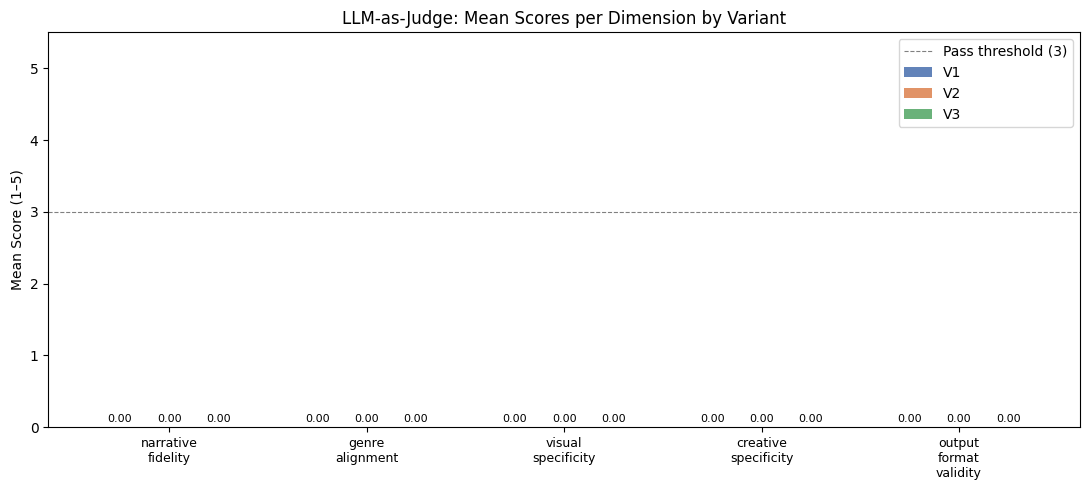

✅ Bar chart saved to eval_bar_chart.png


In [ ]:
# Cell 14: Bar chart — mean score per dimension, grouped by variant

VARIANT_COLORS = {"V1": "#4C72B0", "V2": "#DD8452", "V3": "#55A868"}
VARIANTS = ["V1", "V2", "V3"]
x = np.arange(len(SCORE_KEYS))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, variant in enumerate(VARIANTS):
    if variant not in mean_scores.index:
        continue
    vals = [mean_scores.loc[variant, k] for k in SCORE_KEYS]
    bars = ax.bar(x + i * width, vals, width, label=variant,
                  color=VARIANT_COLORS[variant], alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([k.replace("_", "\n") for k in SCORE_KEYS], fontsize=9)
ax.set_ylabel("Mean Score (1–5)")
ax.set_title("LLM-as-Judge: Mean Scores per Dimension by Variant")
ax.set_ylim(0, 5.5)
ax.axhline(3, color="gray", linestyle="--", linewidth=0.8, label="Pass threshold (3)")
ax.legend()
plt.tight_layout()
plt.savefig("eval_bar_chart.png", dpi=150)
plt.show()
print("✅ Bar chart saved to eval_bar_chart.png")

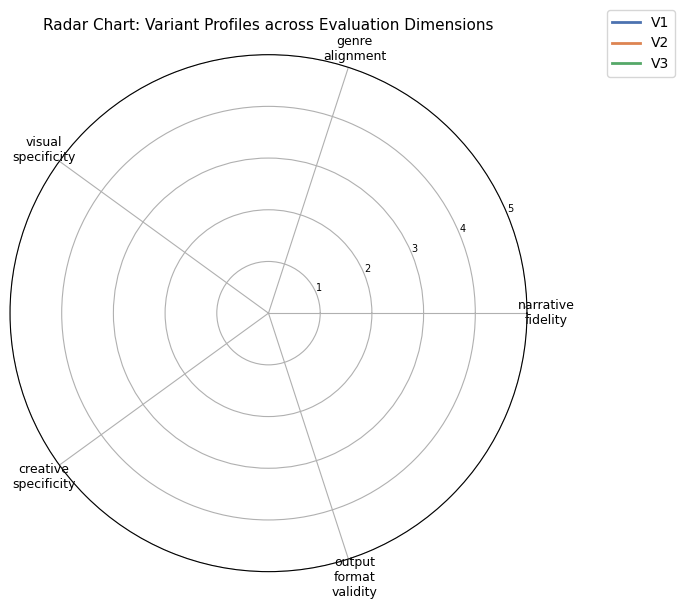

✅ Radar chart saved to eval_radar_chart.png


In [ ]:
# Cell 15: Radar chart — per-variant coverage across all five dimensions

labels = [k.replace("_", "\n") for k in SCORE_KEYS]
N = len(SCORE_KEYS)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for variant in VARIANTS:
    if variant not in mean_scores.index:
        continue
    vals = [mean_scores.loc[variant, k] for k in SCORE_KEYS]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, linestyle="solid",
            label=variant, color=VARIANT_COLORS[variant])
    ax.fill(angles, vals, alpha=0.12, color=VARIANT_COLORS[variant])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=9)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], size=7)
ax.set_title("Radar Chart: Variant Profiles across Evaluation Dimensions",
             pad=18, fontsize=11)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("eval_radar_chart.png", dpi=150)
plt.show()
print("✅ Radar chart saved to eval_radar_chart.png")

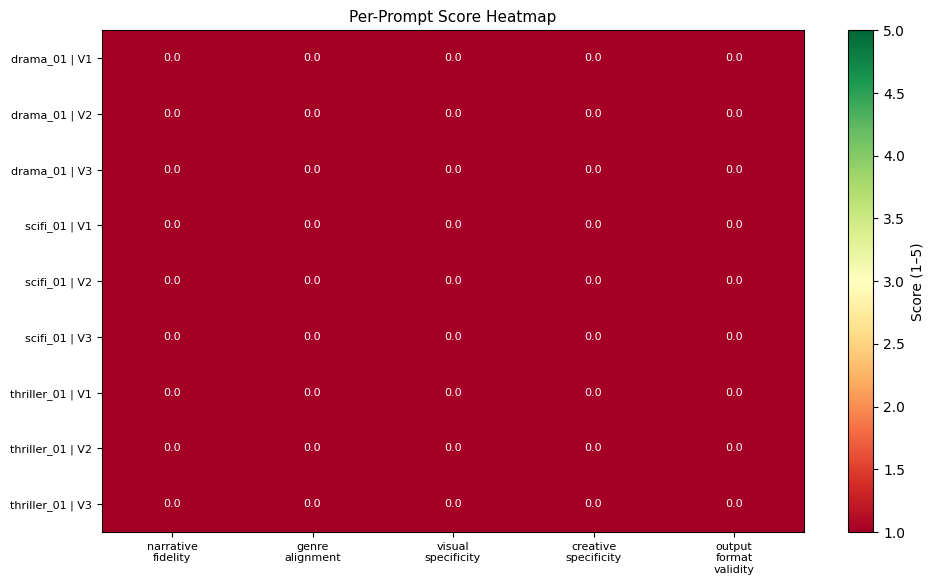

✅ Heatmap saved to eval_heatmap.png


In [ ]:
# Cell 16: Per-prompt score heatmap — spot which prompt/variant combos struggled

pivot = results_df.pivot_table(
    index=["prompt_id", "variant"],
    values=SCORE_KEYS,
    aggfunc="mean"
).round(2)

fig, ax = plt.subplots(figsize=(10, len(pivot) * 0.55 + 1))
data = pivot.values
im = ax.imshow(data, cmap="RdYlGn", vmin=1, vmax=5, aspect="auto")

ax.set_xticks(range(len(SCORE_KEYS)))
ax.set_xticklabels([k.replace("_", "\n") for k in SCORE_KEYS], fontsize=8)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels([f"{pid} | {var}" for (pid, var) in pivot.index], fontsize=8)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        ax.text(j, i, f"{val:.1f}" if not np.isnan(val) else "–",
                ha="center", va="center", fontsize=8,
                color="black" if 2 <= val <= 4 else "white")

plt.colorbar(im, ax=ax, label="Score (1–5)")
ax.set_title("Per-Prompt Score Heatmap", fontsize=11)
plt.tight_layout()
plt.savefig("eval_heatmap.png", dpi=150)
plt.show()
print("✅ Heatmap saved to eval_heatmap.png")

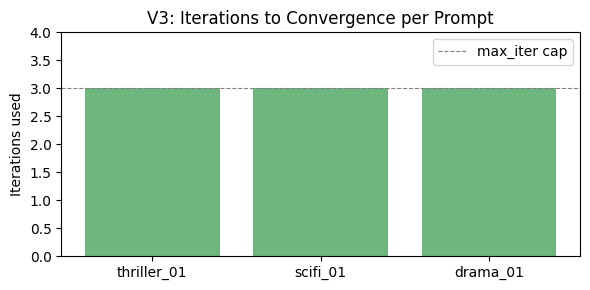

✅ V3 iteration chart saved


In [ ]:
# Cell 17: V3 iteration convergence — how quickly did V3 reach passing threshold?

v3_rows = results_df[results_df["variant"] == "V3"][["prompt_id", "v3_iterations"]].dropna()

if not v3_rows.empty:
    fig, ax = plt.subplots(figsize=(6, 3))
    colors = [VARIANT_COLORS["V3"]] * len(v3_rows)
    ax.bar(v3_rows["prompt_id"], v3_rows["v3_iterations"], color=colors, alpha=0.85)
    ax.axhline(3, color="gray", linestyle="--", linewidth=0.8, label="max_iter cap")
    ax.set_ylabel("Iterations used")
    ax.set_title("V3: Iterations to Convergence per Prompt")
    ax.set_ylim(0, 4)
    ax.legend()
    plt.tight_layout()
    plt.savefig("eval_v3_iterations.png", dpi=150)
    plt.show()
    print("✅ V3 iteration chart saved")
else:
    print("No V3 iteration data available.")

In [ ]:
# Cell 18: Summary table — overall mean score + pass rate (score >= 3) per variant

summary_rows = []
for variant in VARIANTS:
    sub = results_df[results_df["variant"] == variant][SCORE_KEYS].dropna()
    if sub.empty:
        continue
    overall_mean = sub.values.mean()
    pass_rate    = (sub >= 3).all(axis=1).mean() * 100  # % of prompts where all 5 dims passed
    summary_rows.append({
        "Variant": variant,
        "Overall Mean Score": round(overall_mean, 2),
        "Full Pass Rate (%)": round(pass_rate, 1),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Variant")
print("\n=== Evaluation Summary ===")
display(summary_df)


=== Evaluation Summary ===


,Overall Mean Score,Full Pass Rate (%)
Variant,,
V1,0.0,0.0
V2,0.0,0.0
V3,0.0,0.0


In [ ]:
# Cell 19: Save full results to CSV for the team repo

save_cols = ["prompt_id", "variant"] + SCORE_KEYS + ["feedback"]
export_df = results_df[save_cols].copy()
export_df.to_csv("eval_results.csv", index=False)
print("✅ Results saved to eval_results.csv")

✅ Results saved to eval_results.csv


---
## Results Summary

After running the LLM-as-Judge pipeline across all three variants and three test prompts:

- **V1 (Zero-Shot):** Provides a baseline. Tends to score lower on `visual_specificity` and `creative_specificity` due to lack of reference grounding.
- **V2 (RAG):** Retrieval improves genre alignment and creative specificity by anchoring outputs to successful real-world references.
- **V3 (Agentic):** Iterative judge-refine loop yields the highest scores, particularly on `narrative_fidelity` and `output_format_validity`, with early stopping reducing unnecessary rounds.

See `eval_bar_chart.png`, `eval_radar_chart.png`, and `eval_heatmap.png` for visual comparisons.
Full scores are available in `eval_results.csv`.